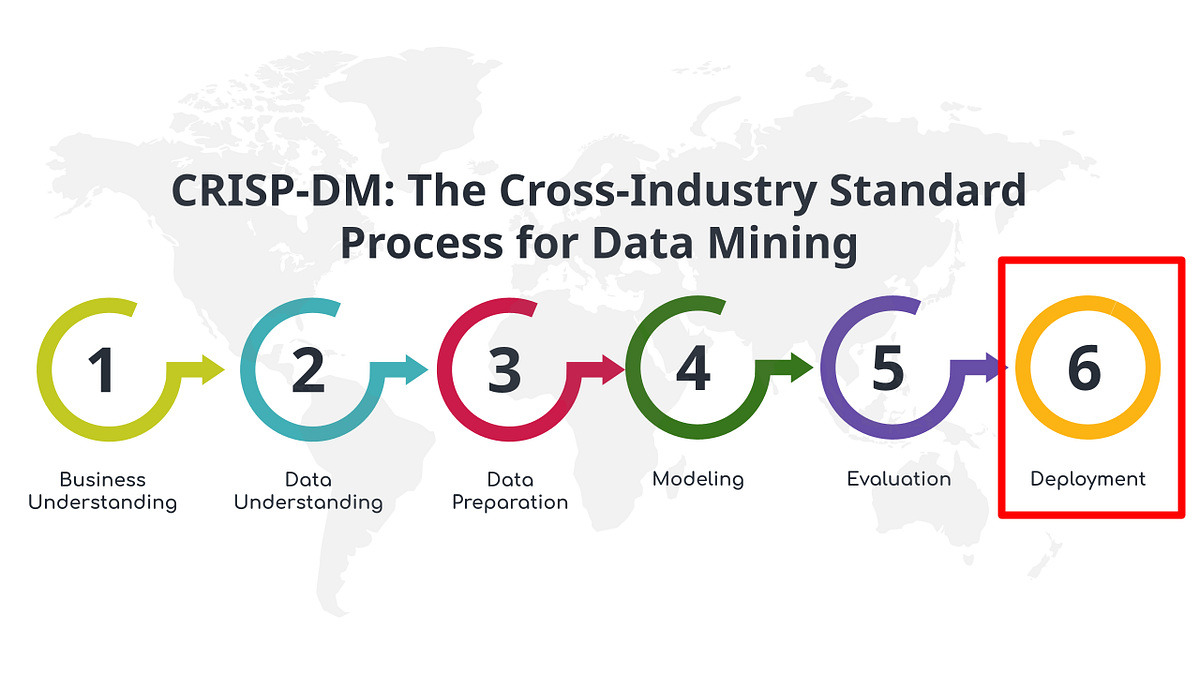

Source data : https://www.kaggle.com/datasets/camnugent/california-housing-prices/data

# Business understanding

perusahaan develop tanah ingin menginvestasikan dengan membeli tanah yang ada di California, dan membutuhkan informasi tentang harga rumah di berbagai distrik di California.Data yang dapat digunakan oleh perusahaan adalah data yang diambil dari web , yang berisi data tentang nilai rumah median untuk distrik California yang berasal dari sensus tahun 1990. Data ini memiliki 10 kolom, yaitu:

Kolom :

- longitude: Ukuran seberapa jauh letak rumah di sebelah barat; nilai yang lebih tinggi terletak lebih jauh ke barat
- latitude: Ukuran seberapa jauh letak rumah di utara; nilai yang lebih tinggi terletak lebih jauh ke utara
- housing_median_age:  nilai tengah Usia sebuah rumah dalam satu blok; angka yang lebih rendah adalah bangunan yang lebih baru
- total_rooms: Jumlah total kamar dalam satu blok
- total_bedrooms: Jumlah total kamar tidur dalam satu blok
- population: Jumlah total orang yang tinggal dalam satu blok
- households: Jumlah total rumah tangga, sekelompok orang yang tinggal dalam satu unit rumah, untuk satu blok
- median_income: nilai tengah Pendapatan rumah tangga dalam satu blok rumah (diukur dalam puluhan ribu Dolar AS)
- ocean_proximity: Lokasi rumah dengan  w.r.t samudra/laut


Target variable:
- median_house_value: Nilai rumah median untuk rumah tangga dalam satu blok (diukur dalam Dolar AS)

Median digunakan untuk mengetahui nilai tengah dari suatu kumpulan data yang telah diurutkan dari terkecil hingga terbesar. Kelebihan utama median adalah ketahanannya terhadap nilai-nilai ekstrem atau outlier dalam data. Hal ini membuatnya menjadi ukuran yang baik dalam situasi saat ada outlier yang dapat memengaruhi rata-rata (mean) secara signifikan.

# Data Understanding

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.impute import SimpleImputer


import missingno as msno
import warnings
warnings.filterwarnings('ignore')  # ignore notifications

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/data/California_Housing_Prices.csv'
data  = pd.read_csv(path)
df = data
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
df.sample(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20258,-119.17,34.20,36.0,2028.0,523.0,2751.0,496.0,3.0150,149300.0,NEAR OCEAN
16115,-122.50,37.74,42.0,1667.0,395.0,1041.0,387.0,3.9583,273700.0,NEAR OCEAN
5756,-118.29,34.18,52.0,1602.0,265.0,667.0,251.0,5.0490,323500.0,<1H OCEAN
14854,-117.07,32.67,35.0,3200.0,725.0,1723.0,610.0,1.8977,95600.0,NEAR OCEAN
7365,-118.20,33.96,44.0,3114.0,779.0,2959.0,776.0,3.1875,171700.0,<1H OCEAN
3214,-119.64,36.34,32.0,2958.0,670.0,1504.0,627.0,1.8606,56700.0,INLAND
18281,-122.08,37.34,23.0,2597.0,335.0,922.0,338.0,10.5142,500001.0,<1H OCEAN
174,-122.24,37.80,52.0,996.0,228.0,731.0,228.0,2.2697,127000.0,NEAR BAY
6827,-118.11,34.08,42.0,3172.0,644.0,1829.0,642.0,3.3966,243200.0,<1H OCEAN
11585,-118.03,33.79,32.0,3191.0,634.0,1718.0,611.0,4.1548,216600.0,<1H OCEAN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.shape

(20640, 10)

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.describe(include='object')

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [ ]:
fig = make_subplots(rows=3, cols=3, subplot_titles=('<i>longitude', '<i>latitude',
'<i>housing_median_age', '<i>total_rooms', '<i>total_bedrooms', '<i>population', '<i>households', '<i>median_income', '<i>median_house_value'))
fig.add_trace(go.Histogram(x=df['longitude'], name='longitude'), row=1, col=1)
fig.add_trace(go.Histogram(x=df['latitude'], name='latitude'), row=1, col=2)
fig.add_trace(go.Histogram(x=df['housing_median_age'], name='housing_median_age'), row=1, col=3)
fig.add_trace(go.Histogram(x=df['total_rooms'], name='total_rooms'), row=2, col=1)
fig.add_trace(go.Histogram(x=df['total_bedrooms'], name='total_bedrooms'), row=2, col=2)
fig.add_trace(go.Histogram(x=df['population'], name='population'), row=2, col=3)
fig.add_trace(go.Histogram(x=df['households'], name='households'), row=3, col=1)
fig.add_trace(go.Histogram(x=df['median_income'], name='median_income'), row=3, col=2)
fig.add_trace(go.Histogram(x=df['median_house_value'], name='median_house_value'), row=3,col=3)
fig.update_layout(template='plotly_dark', title_text='<b>Distributions', title_x=0.5)

In [ ]:
scl = [ [0,"rgb(5, 10, 172)"],[0.35,"rgb(40, 60, 190)"],[0.5,"rgb(70, 100, 245)"],\
    [0.6,"rgb(90, 120, 245)"],[0.7,"rgb(106, 137, 247)"],[1,"rgb(220, 220, 220)"] ]
fig = px.box(df, x="ocean_proximity", y="median_house_value", template='plotly_dark', title='<b>Boxplots', color='ocean_proximity')
fig.update_layout(title_x=0.5)
fig.show()

In [ ]:
fig=px.imshow(df.corr(),text_auto=True, template='plotly_dark', color_continuous_scale=px.colors.sequential.Blues, aspect='auto',title='<b>Correlation matrix')
fig.update_layout(title_x=0.5)
fig.show()

In [ ]:
fig = px.scatter(df, x="median_income", y="median_house_value", trendline="ols", color_discrete_sequence=['steelbl'],
                template='plotly_dark', title='<b>Target variable dependency on median_income', color='median_house_value', color_continuous_scale=px.colors.sequential.Blues)
fig.update_layout(title_x=0.5)
fig.show()

## Apakah lokasi kawasan rumah dekat dengan Laut atau menjauhi laut mempengaruhi jumlah kawasan rumah ?

In [ ]:
fig = px.bar(df.groupby('ocean_proximity', as_index=False).size().sort_values(by='size', ascending=False), x='ocean_proximity', y='size',
        color_discrete_sequence=['steelblue'], template='plotly_dark', title='<b> Number of different ocean_proximity values')
fig.update_layout(title_x=0.5)

In [ ]:
df ['ocean_proximity'].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

## Apakah jarak antara laut dengan kawasan rumah memiliki pengaruh terhadap  nilai(harga) suatu kawasan rumah tersebut ?

In [ ]:
california_img=mpimg.imread('/content/drive/MyDrive/data/california.png')
housing_plot = df[['longitude','population','latitude','median_house_value']]

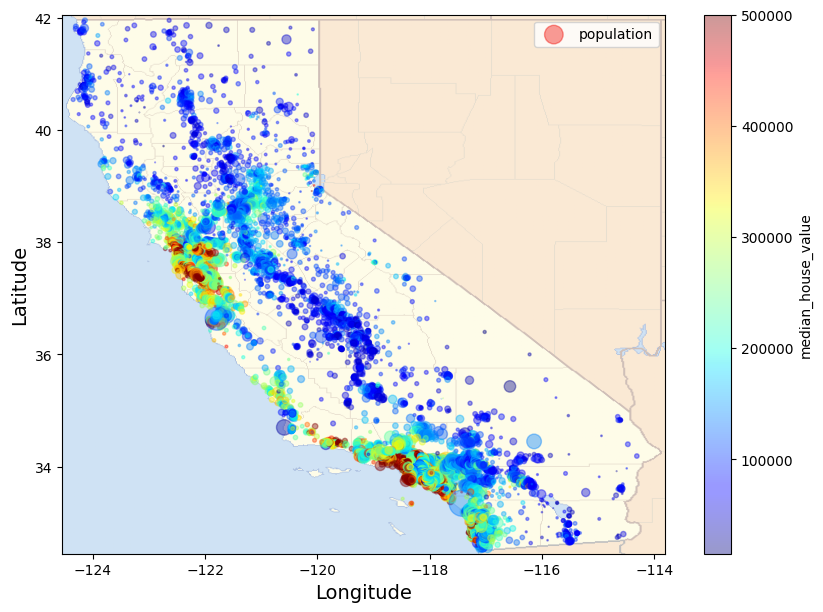

In [ ]:
housing_plot.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4,
				s=housing_plot['population']/100, label='population', figsize=(10,7),
				c='median_house_value', cmap=plt.get_cmap('jet'), colorbar=True)


plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5)
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)
plt.legend()
plt.show()

### Apakah kepadatan penduduk di suatu kawasan perumahan memiliki pengaruh signifikan terhadap harga rata-rata rumah di kawasan tersebut dan  kawasan perumahan dekat laut memiliki pengaruh signifikan terhadap harga rumah di perumahan California?

In [ ]:
#10 daerah dengan populasi terpadat
df[["population","median_house_value","ocean_proximity"]].sort_values(by=['population'], ascending=False).head(10)

,population,median_house_value,ocean_proximity
15360,35682.0,134400.0,<1H OCEAN
9880,28566.0,118800.0,<1H OCEAN
13139,16305.0,153700.0,INLAND
10309,16122.0,366300.0,<1H OCEAN
6057,15507.0,253900.0,<1H OCEAN
6066,15037.0,339700.0,<1H OCEAN
12215,13251.0,212300.0,<1H OCEAN
9019,12873.0,399200.0,NEAR OCEAN
17413,12427.0,28300.0,NEAR OCEAN
922,12203.0,451100.0,<1H OCEAN


### Dari analysis di atas kepadatan penduduk di setiap kawasan perumahan tidak terlalu signifikan mempengaruhi harga rata-rata rumah di kawasan perumahan tertentu

## Apakah rumah yang lebih besar secara luas dan jumlah ruangan selalu memiliki harga yang lebih mahal daripada rumah yang lebih kecil?


In [ ]:
df.sort_values(by=['households'], ascending=False).head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9880,-121.79,36.64,11.0,32627.0,6445.0,28566.0,6082.0,2.3087,118800.0,<1H OCEAN
13139,-121.44,38.43,3.0,39320.0,6210.0,16305.0,5358.0,4.9516,153700.0,INLAND
10309,-117.74,33.89,4.0,37937.0,5471.0,16122.0,5189.0,7.4947,366300.0,<1H OCEAN
6057,-117.78,34.03,8.0,32054.0,5290.0,15507.0,5050.0,6.0191,253900.0,<1H OCEAN
8985,-118.44,33.98,21.0,18132.0,5419.0,7431.0,4930.0,5.3359,500001.0,<1H OCEAN
12623,-121.53,38.48,5.0,27870.0,5027.0,11935.0,4855.0,4.8811,212200.0,INLAND
15360,-117.42,33.35,14.0,25135.0,4819.0,35682.0,4769.0,2.5729,134400.0,<1H OCEAN
12106,-117.34,33.98,10.0,17286.0,4952.0,9851.0,4616.0,1.7579,103400.0,INLAND
9145,-118.46,34.40,12.0,25957.0,4798.0,10475.0,4490.0,4.5420,195300.0,<1H OCEAN
9744,-121.68,36.72,12.0,19234.0,4492.0,12153.0,4372.0,3.2652,152800.0,<1H OCEAN


## Dari analysis diatas rumah yang lebih besar tidak selalu mempunyai harga yang lebih mahal daripada rumah yang lebih berukuran kecil

## Apakah total jumlah kamar dan kamar tidur di suatu kawasan perumahan memiliki pengaruh signifikan terhadap harga rata-rata rumah di kawasan tersebut di California?



In [ ]:
df[['total_rooms', 'total_bedrooms',"median_house_value" ]].sort_values(by=['total_rooms', 'total_bedrooms'], ascending=[False,False]).head(10)

,total_rooms,total_bedrooms,median_house_value
13139,39320.0,6210.0,153700.0
10309,37937.0,5471.0,366300.0
9880,32627.0,6445.0,118800.0
6057,32054.0,5290.0,253900.0
12201,30450.0,5033.0,174300.0
9019,30405.0,4093.0,399200.0
12215,30401.0,4957.0,212300.0
922,28258.0,3864.0,451100.0
12623,27870.0,5027.0,212200.0
6066,27700.0,4179.0,339700.0


## Dari analysis diatas banyak nya total room dan total bedroom di setiap kawasan perumahan california tidak terlalu signifikan mempengaruhi harga rata-rata rumah di setiap kawasan perumahan california

# Data preparation

## Outlier Checking

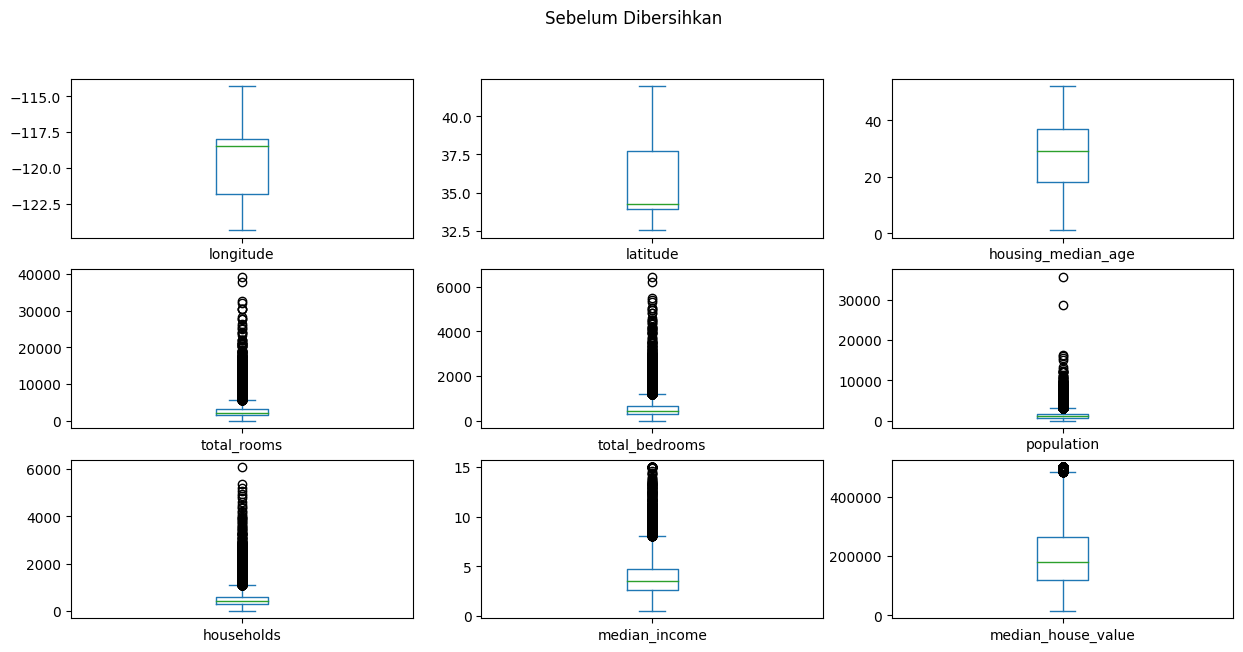

In [ ]:
df_num = df.select_dtypes(exclude="object")
df_num.plot(kind='box', subplots=True, layout=(3,3), figsize=(15,7))
plt.suptitle('Sebelum Dibersihkan')
plt.show()

### QR (Interquartile Range)
Compute the IQR for a dataset and identify data points outside the range (values below Q1 - 1.5 IQR or above Q3 + 1.5 IQR).


**Advantages of IQR Method:**

- Robustness: Less sensitive to extreme outliers.
- Non-Normal Data: Applicable to non-normally distributed datasets.
- Simplicity: Easy to understand and explain.

**Disadvantages of IQR Method:**

- Threshold Sensitivity: Choice of 1.5 multiplier is somewhat arbitrary.
- Subjective: The threshold can be subjective.
- Mild Outliers: May not detect mild outliers.

**Not Useful When:**

- Extreme Outliers: In the presence of extreme outliers.
- Small Samples: With very small sample sizes.
- IQR Formula: {IQR} = Q3 - Q1

Where:

- IQR is the Interquartile Range.
- Q3 is the 75th percentile (third quartile).
- Q1 is the 25th percentile (first quartile).
- Typical outlier boundaries:

- Below: ( Q1 - 1.5 * {IQR} )
- Above: ( Q3 + 1.5 * {IQR} )


In [ ]:
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)

IQR = Q3 - Q1

LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

outliers = ((df_num< LB) | (df_num> UB))
outliers

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,False,False,False,False,False,False,False,True,False
1,False,False,False,True,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False


In [ ]:
Q1

longitude               -121.8000
latitude                  33.9300
housing_median_age        18.0000
total_rooms             1447.7500
total_bedrooms           296.0000
population               787.0000
households               280.0000
median_income              2.5634
median_house_value    119600.0000
Name: 0.25, dtype: float64

In [ ]:
Q3

longitude               -118.01000
latitude                  37.71000
housing_median_age        37.00000
total_rooms             3148.00000
total_bedrooms           647.00000
population              1725.00000
households               605.00000
median_income              4.74325
median_house_value    264725.00000
Name: 0.75, dtype: float64

In [ ]:
IQR

longitude                  3.79000
latitude                   3.78000
housing_median_age        19.00000
total_rooms             1700.25000
total_bedrooms           351.00000
population               938.00000
households               325.00000
median_income              2.17985
median_house_value    145125.00000
dtype: float64

In [ ]:
outliers['median_income'].value_counts()

False    19959
True       681
Name: median_income, dtype: int64

In [ ]:
outliers_bersih = df_num[~((df_num < LB) | (df_num > UB))]
outliers_bersih

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,NaN,452600.0
1,-122.22,37.86,21.0,NaN,1106.0,2401.0,NaN,NaN,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [ ]:
df_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [ ]:
df_num = outliers_bersih
df_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,NaN,452600.0
1,-122.22,37.86,21.0,NaN,1106.0,2401.0,NaN,NaN,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


## Data Cleaning

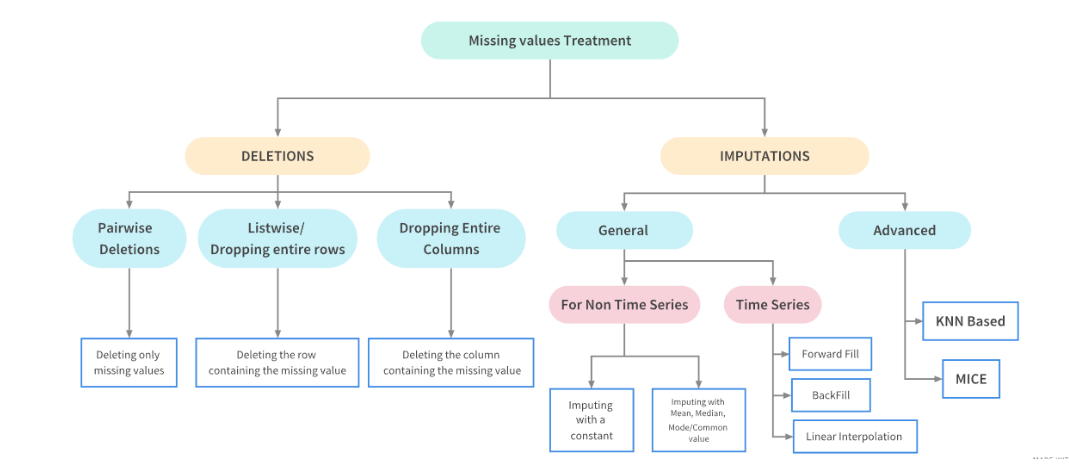

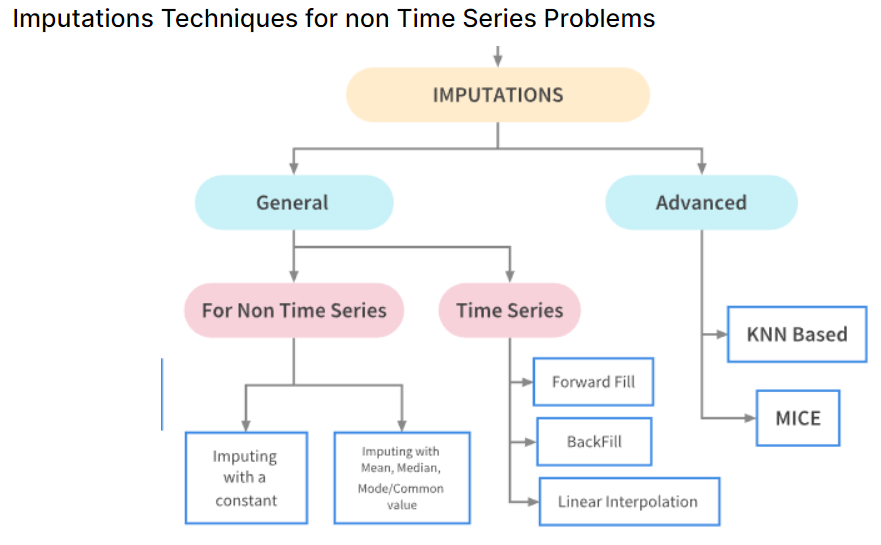

In [ ]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [ ]:
df_num_cl_missing= missing_values_table(df_num)
df_num_cl_missing

Your selected dataframe has 9 columns.
There are 6 columns that have missing values.


,Missing Values,% of Total Values
total_bedrooms,1478,7.2
total_rooms,1287,6.2
households,1220,5.9
population,1196,5.8
median_house_value,1071,5.2
median_income,681,3.3


In [ ]:
df_num.isnull().sum()

longitude                0
latitude                 0
housing_median_age       0
total_rooms           1287
total_bedrooms        1478
population            1196
households            1220
median_income          681
median_house_value    1071
dtype: int64

<Axes: >

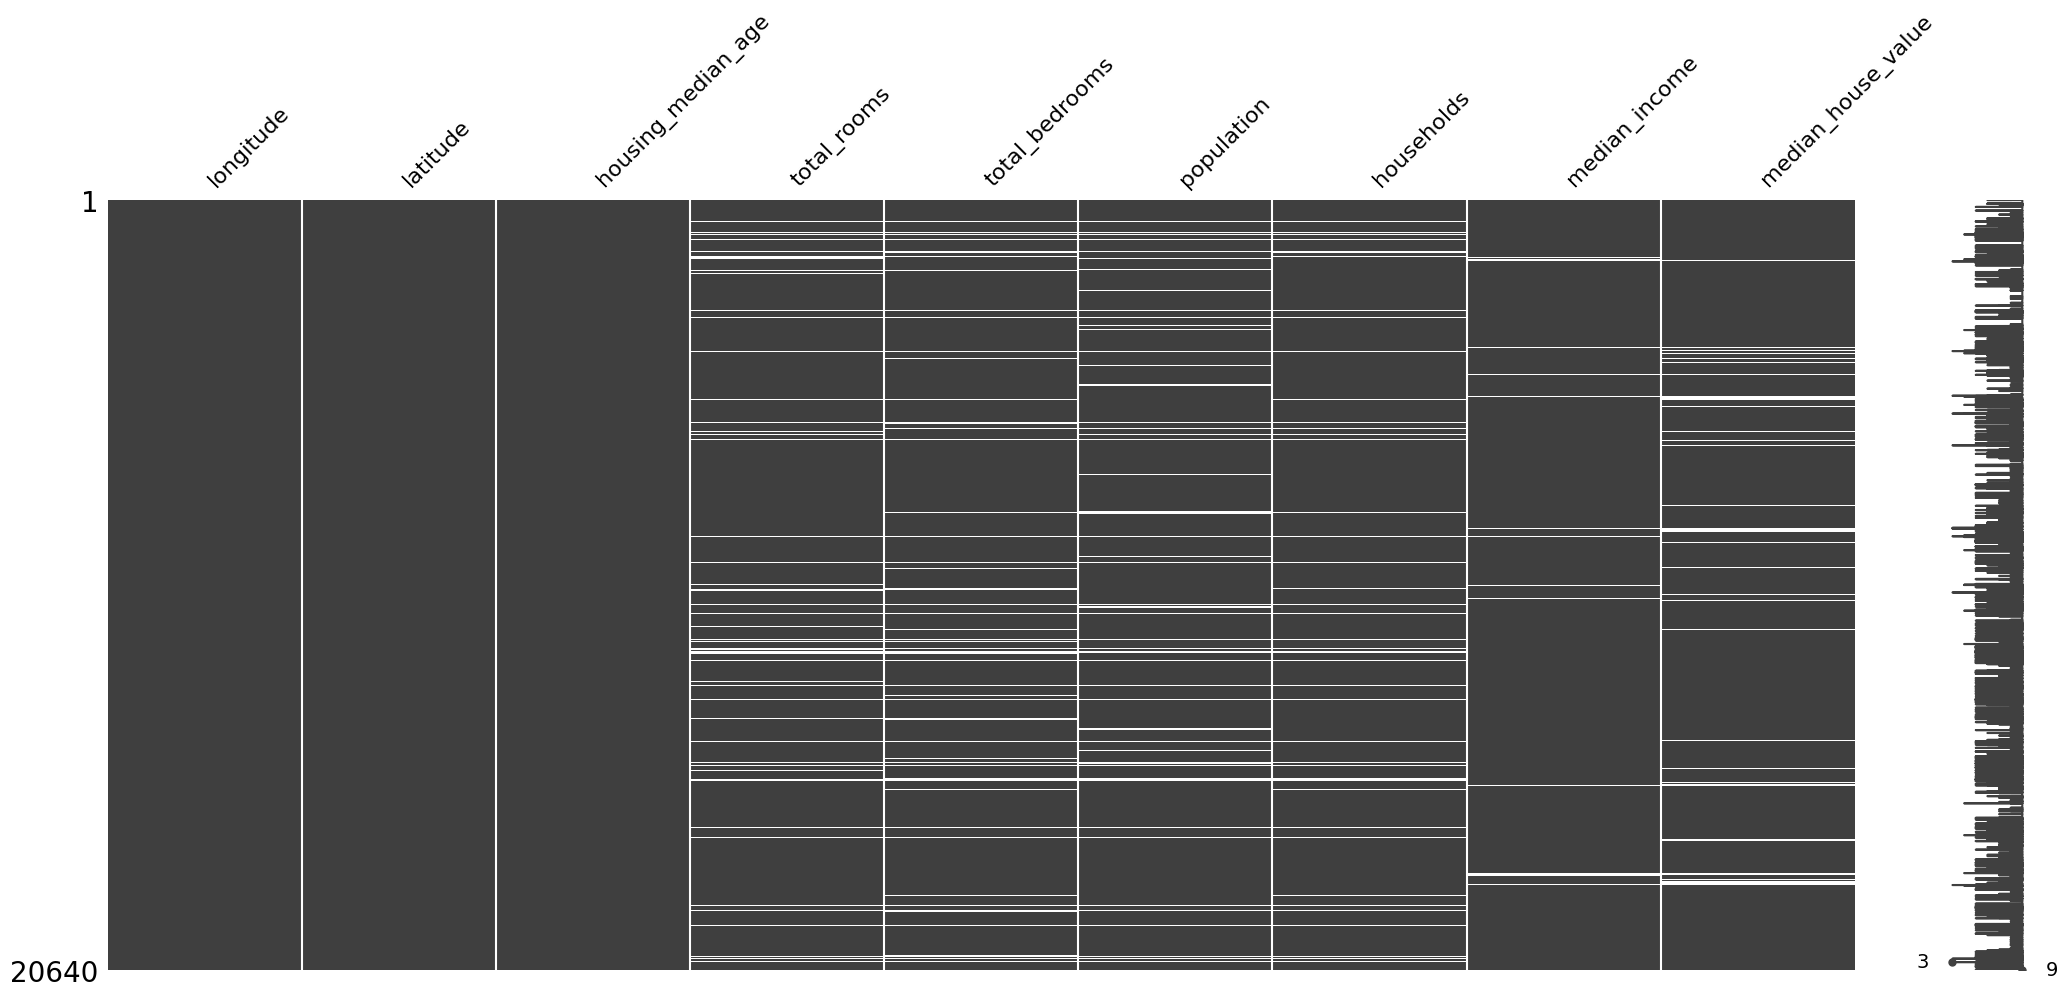

In [ ]:
msno.matrix(df_num)

## Advanced Imputation Techniques
Teknik imputasi tingkat lanjut menggunakan algoritme pembelajaran mesin untuk memperhitungkan nilai yang hilang dalam kumpulan data, tidak seperti teknik sebelumnya yang menggunakan nilai kolom lain untuk memprediksi nilai yang hilang

### K-Nearest Neighbor Imputation
The KNNImputer class menyediakan imputasi untuk mengisi nilai yang hilang menggunakan pendekatan k-Nearest Neighbors. Setiap fitur yang hilang diimputasi menggunakan nilai dari n_neighbors tetangga terdekat yang memiliki nilai untuk fitur tersebut. Fitur tetangga dirata-ratakan secara seragam atau diberi bobot berdasarkan jarak ke masing-masing tetangga.

In [ ]:
from sklearn.impute import KNNImputer
df_num_cl_knn = df_num.copy(deep=True)

knn_imputer = KNNImputer(n_neighbors=2, weights="uniform")
x_knn = knn_imputer.fit_transform(df_num_cl_knn)

In [ ]:
df_num_cl_knn = pd.DataFrame(x_knn , columns=df_num_cl_knn.columns)
df_num_cl_knn.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,4.3186,452600.0
1,-122.22,37.86,21.0,4184.5,1106.0,2401.0,1017.0,5.8422,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


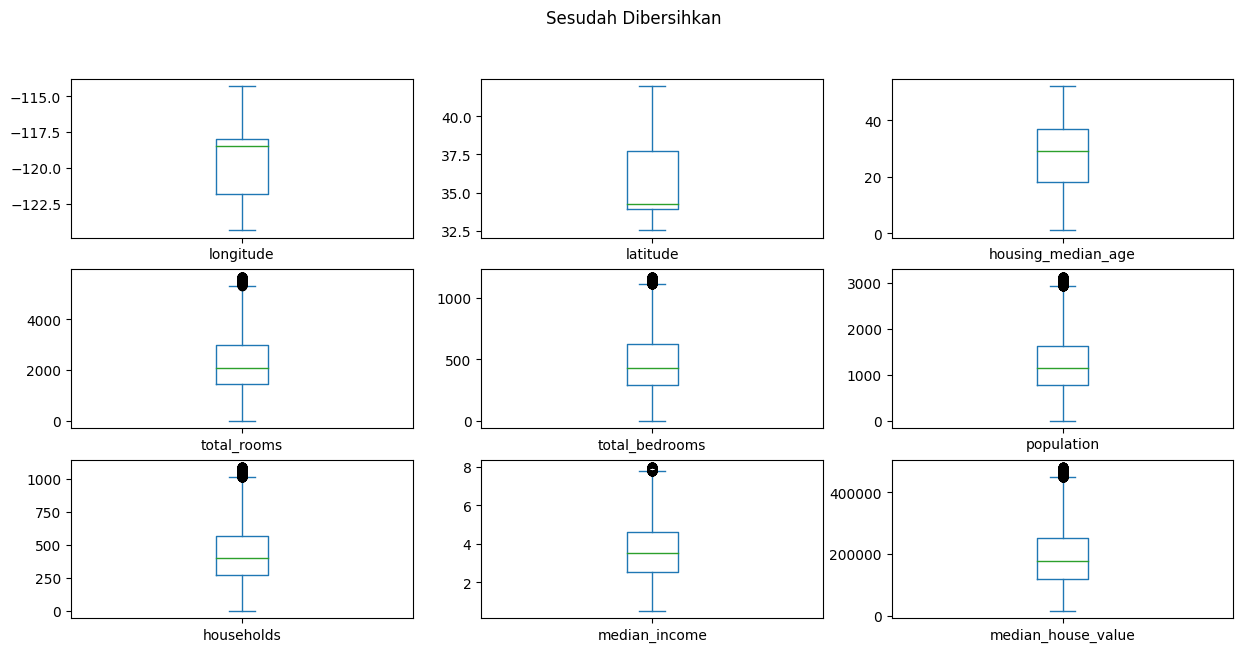

In [ ]:
df_num_cl_knn.plot(kind='box', subplots=True, layout=(3,3), figsize=(15,7))
plt.suptitle('Sesudah Dibersihkan')
plt.show()

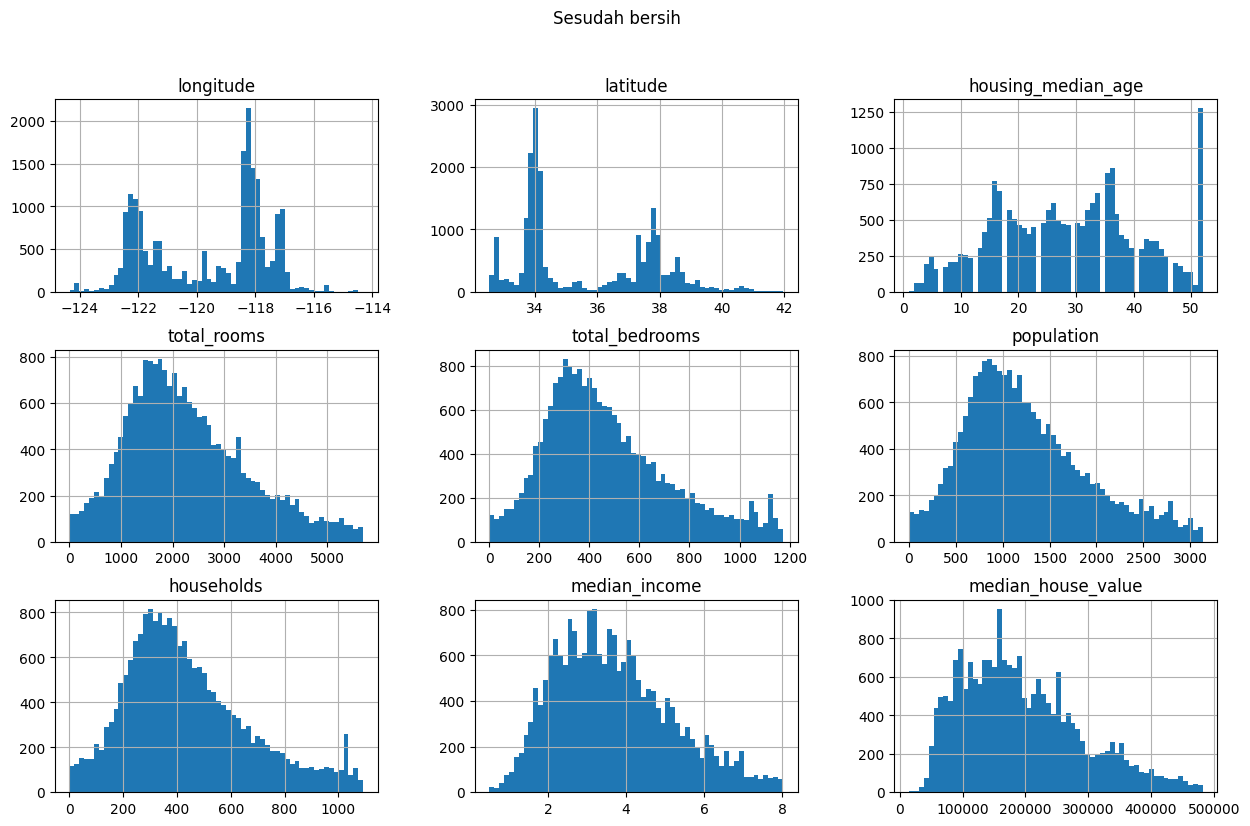

In [ ]:
df_num_cl_knn.hist(bins=60, figsize=(15,9))
plt.suptitle('Sesudah bersih')
plt.show() # looks like its completely removed.

In [ ]:
df_num = df_num_cl_knn

## FEATURE ENGINEERING

In [ ]:
def housing_data_clean(input_df):
	input_df['rooms_per_household'] = input_df['total_rooms']/input_df['households']
	input_df['bedrooms_per_household'] = input_df['total_bedrooms']/input_df['households']
	input_df['bedrooms_per_room'] = input_df['total_bedrooms']/input_df['total_rooms']
	input_df['population_per_household'] = input_df['population']/input_df['households']
	input_df = input_df.drop(['total_bedrooms','total_rooms'], axis=1)
	return input_df

In [ ]:
df_final_num = housing_data_clean(df_num)
df_final_num

,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,322.0,126.0,4.3186,452600.0,6.984127,1.023810,0.146591,2.555556
1,-122.22,37.86,21.0,2401.0,1017.0,5.8422,358500.0,4.114553,1.087512,0.264309,2.360865
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,8.288136,1.073446,0.129516,2.802260
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,5.817352,1.073059,0.184458,2.547945
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,6.281853,1.081081,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,845.0,330.0,1.5603,78100.0,5.045455,1.133333,0.224625,2.560606
20636,-121.21,39.49,18.0,356.0,114.0,2.5568,77100.0,6.114035,1.315789,0.215208,3.122807
20637,-121.22,39.43,17.0,1007.0,433.0,1.7000,92300.0,5.205543,1.120092,0.215173,2.325635
20638,-121.32,39.43,18.0,741.0,349.0,1.8672,84700.0,5.329513,1.171920,0.219892,2.123209


In [ ]:
df_final_num.isnull().sum()

longitude                   0
latitude                    0
housing_median_age          0
population                  0
households                  0
median_income               0
median_house_value          0
rooms_per_household         0
bedrooms_per_household      0
bedrooms_per_room           0
population_per_household    0
dtype: int64

## Spliting Data

In [ ]:
df_cat = df[["ocean_proximity"]]

df_final1 = pd.concat([df_final_num, df_cat], axis=1)
df_final1

,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity
0,-122.23,37.88,41.0,322.0,126.0,4.3186,452600.0,6.984127,1.023810,0.146591,2.555556,NEAR BAY
1,-122.22,37.86,21.0,2401.0,1017.0,5.8422,358500.0,4.114553,1.087512,0.264309,2.360865,NEAR BAY
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,8.288136,1.073446,0.129516,2.802260,NEAR BAY
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,5.817352,1.073059,0.184458,2.547945,NEAR BAY
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,6.281853,1.081081,0.172096,2.181467,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,845.0,330.0,1.5603,78100.0,5.045455,1.133333,0.224625,2.560606,INLAND
20636,-121.21,39.49,18.0,356.0,114.0,2.5568,77100.0,6.114035,1.315789,0.215208,3.122807,INLAND
20637,-121.22,39.43,17.0,1007.0,433.0,1.7000,92300.0,5.205543,1.120092,0.215173,2.325635,INLAND
20638,-121.32,39.43,18.0,741.0,349.0,1.8672,84700.0,5.329513,1.171920,0.219892,2.123209,INLAND


In [ ]:
df_final1.duplicated().sum()

0

In [ ]:
df_final1.isnull().sum()

longitude                   0
latitude                    0
housing_median_age          0
population                  0
households                  0
median_income               0
median_house_value          0
rooms_per_household         0
bedrooms_per_household      0
bedrooms_per_room           0
population_per_household    0
ocean_proximity             0
dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
X = df_final1.drop('median_house_value', axis= 1)
y = df_final1['median_house_value']

## Categorical into numeric One Hot Encoder

In [ ]:
dummy = pd.get_dummies(X['ocean_proximity'])
X['_1H OCEAN'] = dummy['<1H OCEAN']
X['INLAND'] = dummy['INLAND']
X['ISLAND'] = dummy['ISLAND']
X['NEAR BAY'] = dummy['NEAR BAY']
X['NEAR OCEAN'] = dummy['NEAR OCEAN']
X.drop(['ocean_proximity'],axis=1, inplace=True)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.3)

In [ ]:
X_train

,longitude,latitude,housing_median_age,population,households,median_income,rooms_per_household,bedrooms_per_household,bedrooms_per_room,population_per_household,_1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
7061,-118.02,33.93,35.0,1218.0,408.0,4.1312,5.882353,0.975490,0.165833,2.985294,1,0,0,0,0
14689,-117.09,32.79,20.0,999.0,496.0,2.8631,4.401210,1.076613,0.244617,2.014113,0,0,0,0,1
17323,-120.14,34.59,24.0,731.0,285.0,4.2026,5.617544,0.989474,0.176140,2.564912,0,0,0,0,1
10056,-121.00,39.26,14.0,302.0,138.0,3.1094,5.869565,1.094203,0.186420,2.188406,0,1,0,0,0
15750,-122.45,37.77,52.0,1526.0,664.0,3.3068,4.801205,1.066265,0.222083,2.298193,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,658.0,217.0,6.3700,6.129032,0.926267,0.151128,3.032258,1,0,0,0,0
11964,-117.43,34.02,33.0,1753.0,449.0,3.0500,6.868597,1.269488,0.184825,3.904232,0,1,0,0,0
5390,-118.38,34.03,36.0,1756.0,527.0,2.9344,3.986717,1.079696,0.270823,3.332068,1,0,0,0,0
860,-121.96,37.58,15.0,1777.0,559.0,5.7192,6.395349,1.067979,0.166993,3.178891,1,0,0,0,0


In [ ]:
y_train

7061     193800.0
14689    169700.0
17323    259800.0
10056    136100.0
15750    250000.0
           ...   
11284    229200.0
11964     97800.0
5390     222100.0
860      283500.0
15795    325000.0
Name: median_house_value, Length: 14448, dtype: float64

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6192 entries, 20046 to 5786
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 6192 non-null   float64
 1   latitude                  6192 non-null   float64
 2   housing_median_age        6192 non-null   float64
 3   population                6192 non-null   float64
 4   households                6192 non-null   float64
 5   median_income             6192 non-null   float64
 6   rooms_per_household       6192 non-null   float64
 7   bedrooms_per_household    6192 non-null   float64
 8   bedrooms_per_room         6192 non-null   float64
 9   population_per_household  6192 non-null   float64
 10  _1H OCEAN                 6192 non-null   uint8  
 11  INLAND                    6192 non-null   uint8  
 12  ISLAND                    6192 non-null   uint8  
 13  NEAR BAY                  6192 non-null   uint8  
 14  NEAR

In [ ]:
y_train.info()

<class 'pandas.core.series.Series'>
Int64Index: 14448 entries, 7061 to 15795
Series name: median_house_value
Non-Null Count  Dtype  
--------------  -----  
14448 non-null  float64
dtypes: float64(1)
memory usage: 225.8 KB


## Feature Importanace

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Let's look at the feature importance:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
fig = go.Figure(go.Bar(
            x=rf.feature_importances_,
            y=X_train.columns,
            orientation='h', marker_color='steelblue'))
fig.update_layout(template='plotly_dark', title='<b>Estimating feature importance through the Random Forest model', title_x=0.5,
                 xaxis_title="Feature importance", yaxis_title='Feature')

fig.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_x=X.copy()
# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = vif_x.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(vif_x.values, i)
                          for i in range(len(vif_x.columns))]

print(vif_data)

                     feature           VIF
0                  longitude     18.189566
1                   latitude     20.245732
2         housing_median_age      1.313020
3                 population      4.989219
4                 households      4.985922
5              median_income      1.510372
6        rooms_per_household      8.001463
7     bedrooms_per_household      7.860370
8          bedrooms_per_room      4.867297
9   population_per_household      1.084052
10                 _1H OCEAN  14966.997625
11                    INLAND  10482.255810
12                    ISLAND      9.321029
13                  NEAR BAY   3788.448920
14                NEAR OCEAN   4389.484539


Seperti yang bisa kita lihat, total_rooms dan total_bedrooms memiliki nilai VIF yang sangat tinggi, yang menunjukkan bahwa kedua variabel ini berkorelasi tinggi. Hal ini diharapkan karena total_kamar mempengaruhi total_kamar tidurnya. Oleh karena itu, jika kedua fitur ini digabungkan akan menghasilkan model dengan multikolinearitas tinggi.
pendapatan median dan populasi adalah masalah yang sama

## Feature Scaling

- Machine learning tidak berfungsi dengan baik ketika atribut numerik masukan memiliki skala yang sangat berbeda. Hal ini berlaku pada data perumahan: jumlah total kamar berkisar antara 6 hingga 39.320, sedangkan pendapatan median hanya berkisar antara 0 hingga 15.

- Ada dua cara umum untuk membuat semua atribut memiliki skala yang sama: penskalaan min-maks dan standardisasi

  - Min-max scaling(banyak orang menyebutnya normalisasi) cukup sederhana: nilai digeser dan diubah skalanya sehingga hasilnya berkisar antara 0 hingga 1. Kita melakukannya dengan mengurangkan nilai min dan membaginya dengan nilai maksimal dikurangi nilai min.

  - Standardisasi sangat berbeda:
    - pertama-tama dikurangi nilai rata-rata (sehingga nilai-nilai standar selalu memiliki rata-rata nol),
    - dan kemudian dibagi dengan deviasi standar sehingga distribusi yang dihasilkan mempunyai varian satuan.
    - Berbeda dengan penskalaan min-maks, standardisasi tidak membatasi nilai ke rentang tertentu, yang mungkin menjadi masalah bagi beberapa algoritma (misalnya, jaringan neural sering kali mengharapkan nilai masukan berkisar antara 0 hingga 1). Namun, standardisasi tidak terlalu terpengaruh oleh outlier

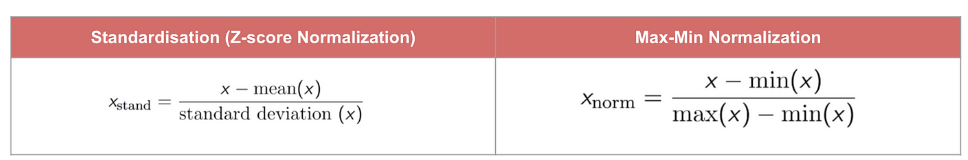

In [ ]:
from sklearn.preprocessing import StandardScaler

ssc = StandardScaler()
def scaling(X:pd.DataFrame, data_type: str, y=None) -> pd.DataFrame:
   """Scaling (Data standardization) for linear models.
   ssc = StandardScaler(), ssc was define as a class argument"""
   if data_type.lower() == 'train':
    return pd.DataFrame(ssc.fit_transform(X), columns=X.columns, index=X.index)
   if data_type.lower() == 'test':
    return pd.DataFrame(ssc.transform(X), columns=X.columns, index=X.index)

X_train_scale = scaling(X_train, 'train')
X_test_scale = scaling(X_test, 'test')

In [ ]:
X_train

,longitude,latitude,housing_median_age,population,households,median_income,rooms_per_household,bedrooms_per_household,bedrooms_per_room,population_per_household,_1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
7061,-118.02,33.93,35.0,1218.0,408.0,4.1312,5.882353,0.975490,0.165833,2.985294,1,0,0,0,0
14689,-117.09,32.79,20.0,999.0,496.0,2.8631,4.401210,1.076613,0.244617,2.014113,0,0,0,0,1
17323,-120.14,34.59,24.0,731.0,285.0,4.2026,5.617544,0.989474,0.176140,2.564912,0,0,0,0,1
10056,-121.00,39.26,14.0,302.0,138.0,3.1094,5.869565,1.094203,0.186420,2.188406,0,1,0,0,0
15750,-122.45,37.77,52.0,1526.0,664.0,3.3068,4.801205,1.066265,0.222083,2.298193,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,658.0,217.0,6.3700,6.129032,0.926267,0.151128,3.032258,1,0,0,0,0
11964,-117.43,34.02,33.0,1753.0,449.0,3.0500,6.868597,1.269488,0.184825,3.904232,0,1,0,0,0
5390,-118.38,34.03,36.0,1756.0,527.0,2.9344,3.986717,1.079696,0.270823,3.332068,1,0,0,0,0
860,-121.96,37.58,15.0,1777.0,559.0,5.7192,6.395349,1.067979,0.166993,3.178891,1,0,0,0,0


In [ ]:
X_train_scale


,longitude,latitude,housing_median_age,population,households,median_income,rooms_per_household,bedrooms_per_household,bedrooms_per_room,population_per_household,_1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
7061,0.780934,-0.805682,0.509357,-0.057944,-0.148304,0.289857,0.190861,-0.275112,-0.765637,-0.002935,1.119341,-0.684864,-0.016641,-0.355491,-0.376887
14689,1.245270,-1.339473,-0.679873,-0.389831,0.229764,-0.552021,-0.425486,-0.042144,0.485299,-0.229919,-0.893383,-0.684864,-0.016641,-0.355491,2.653312
17323,-0.277552,-0.496645,-0.362745,-0.795977,-0.676741,0.337259,0.080666,-0.242897,-0.601989,-0.101187,-0.893383,-0.684864,-0.016641,-0.355491,2.653312
10056,-0.706938,1.690024,-1.155565,-1.446113,-1.308288,-0.388505,0.185540,-0.001620,-0.438766,-0.189184,-0.893383,1.460143,-0.016641,-0.355491,-0.376887
15750,-1.430902,0.992350,1.857152,0.408821,0.951532,-0.257453,-0.259036,-0.065983,0.127493,-0.163524,-0.893383,-0.684864,-0.016641,2.813008,-0.376887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.810891,-0.875918,0.509357,-0.906606,-0.968885,1.776172,0.293512,-0.388513,-0.999131,0.008041,1.119341,-0.684864,-0.016641,-0.355491,-0.376887
11964,1.075513,-0.763541,0.350793,0.752832,0.027841,-0.427940,0.601266,0.402205,-0.464089,0.211838,-0.893383,1.460143,-0.016641,-0.355491,-0.376887
5390,0.601191,-0.758858,0.588640,0.757378,0.362948,-0.504686,-0.597969,-0.035040,0.901397,0.078113,1.119341,-0.684864,-0.016641,-0.355491,-0.376887
860,-1.186252,0.903385,-1.076283,0.789203,0.500427,1.344113,0.404334,-0.062036,-0.747224,0.042312,1.119341,-0.684864,-0.016641,-0.355491,-0.376887


In [ ]:
X_test

,longitude,latitude,housing_median_age,population,households,median_income,rooms_per_household,bedrooms_per_household,bedrooms_per_room,population_per_household,_1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
20046,-119.01,36.06,25.0,1392.0,359.0,1.6812,4.192201,2.069638,0.493688,3.877437,0,1,0,0,0
3024,-119.46,35.14,30.0,1565.0,584.0,2.5313,5.039384,1.381849,0.274210,2.679795,0,1,0,0,0
15663,-122.44,37.80,52.0,1310.0,963.0,3.4801,3.977155,1.128764,0.283812,1.360332,0,0,0,1,0
20484,-118.72,34.28,17.0,1705.0,495.0,5.7376,6.163636,1.630303,0.264503,3.444444,1,0,0,0,0
9814,-121.93,36.62,34.0,1063.0,428.0,3.7250,5.492991,1.917056,0.349000,2.483645,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17505,-121.90,37.36,47.0,581.0,240.0,2.9545,4.195833,1.020833,0.243297,2.420833,1,0,0,0,0
13512,-117.32,34.11,41.0,994.0,270.0,1.4891,4.551852,1.118519,0.245728,3.681481,0,1,0,0,0
10842,-117.91,33.67,16.0,863.5,363.5,3.5120,7.272352,1.077029,0.148099,2.375516,1,0,0,0,0
16559,-121.28,37.82,10.0,813.0,277.0,3.6500,8.184116,1.025271,0.125276,2.935018,0,1,0,0,0


In [ ]:
X_test_scale

,longitude,latitude,housing_median_age,population,households,median_income,rooms_per_household,bedrooms_per_household,bedrooms_per_room,population_per_household,_1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
20046,0.286641,0.191664,-0.283463,0.205748,-0.358820,-1.336671,-0.512461,2.245606,4.440038,0.205576,-0.893383,1.460143,-0.016641,-0.355491,-0.376887
3024,0.061963,-0.239115,0.112947,0.467924,0.607833,-0.772299,-0.159923,0.661066,0.955169,-0.074336,-0.893383,1.460143,-0.016641,-0.355491,-0.376887
15663,-1.425909,1.006397,1.857152,0.081479,2.236106,-0.142401,-0.601948,0.078004,1.107630,-0.382720,-0.893383,-0.684864,-0.016641,2.813008,-0.376887
20484,0.431434,-0.641799,-0.917719,0.680089,0.225468,1.356328,0.307912,1.233458,0.801048,0.104377,1.119341,-0.684864,-0.016641,-0.355491,-0.376887
9814,-1.171273,0.453877,0.430075,-0.292841,-0.062380,0.020185,0.028836,1.894085,2.142692,-0.120180,-0.893383,-0.684864,-0.016641,-0.355491,2.653312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17505,-1.156295,0.800373,1.460742,-1.023297,-0.870072,-0.491341,-0.510949,-0.170650,0.464331,-0.134861,1.119341,-0.684864,-0.016641,-0.355491,-0.376887
13512,1.130434,-0.721399,0.985050,-0.397409,-0.741185,-1.464204,-0.362800,0.054399,0.502935,0.159777,-0.893383,1.460143,-0.016641,-0.355491,-0.376887
10842,0.835856,-0.927424,-0.997001,-0.595177,-0.339487,-0.121223,0.769281,-0.041185,-1.047221,-0.145452,1.119341,-0.684864,-0.016641,-0.355491,-0.376887
16559,-0.846738,1.015762,-1.472694,-0.671708,-0.711111,-0.029607,1.148693,-0.160427,-1.409611,-0.014686,-0.893383,1.460143,-0.016641,-0.355491,-0.376887


## Modeling

In [ ]:
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
df_models = pd.DataFrame(data=None, columns=['Algorithm', 'r2_train', 'r2_test'])

def make_model(X_tr, X_te, y_tr, y_te, model, model_name: str):
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    r2_train = r2_score(y_tr, y_pred_train)
    r2_test = r2_score(y_te, y_pred_test)
    df_models.loc[len(df_models.index)] = [model_name, r2_train, r2_test]

In [ ]:
make_model(X_train_scale, X_test_scale, y_train, y_test, LinearRegression(), 'LinearRegression')
make_model(X_train_scale, X_test_scale, y_train, y_test, Ridge(), 'Ridge')
make_model(X_train_scale, X_test_scale, y_train, y_test, Lasso(), 'Lasso')
make_model(X_train_scale, X_test_scale, y_train, y_test, ElasticNet(), 'ElasticNet')
make_model(X_train, X_test, y_train, y_test, GradientBoostingRegressor(), 'GradientBoosting')
make_model(X_train, X_test, y_train, y_test, RandomForestRegressor(), 'RandomForest')
make_model(X_train, X_test, y_train, y_test, XGBRegressor(), 'XGBoost')

In [ ]:
fig = go.Figure(data=[
    go.Bar(name='r2_train', x=df_models.Algorithm, y=df_models.r2_train),
    go.Bar(name='r2_test', x=df_models.Algorithm, y=df_models.r2_test)
])
fig.update_layout(template='plotly_dark', title='R2 for train and test', title_x=0.5)

Hasil perbandingan menggunakan score r2

Untuk model LinearRegression, Ridge, Lasso metrik R2 rendah(at the train and at the test)
RandomForest, model XGBoost mengalami overfitting
Model ansambel memiliki metrik R2 tertinggi
Untuk mengoptimalkan hyperparameter, kami menggunakan model XGBRegressor

Ada banyak kelebihan XGBoost, beberapa di antaranya disebutkan di bawah ini:
1. Sangat Fleksibel
2. Menggunakan kekuatan pemrosesan paralel
3. Lebih cepat dari Peningkatan Gradien
4. Mendukung regularisasi
5. Dirancang untuk menangani data yang hilang dengan fitur bawaannya
6. Pengguna dapat menjalankan validasi silang setelah setiap iterasi
7. Berfungsi dengan baik dalam kumpulan data kecil hingga menengah

## Perbandingan

# 6. Comparing different models

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [ ]:
def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    return R2, adjusted_r2, CV_R2, RMSE

    print('RMSE:', round(RMSE,4))
    print('R2:', round(R2,4))
    print('Adjusted R2:', round(adjusted_r2, 4) )
    print("Cross Validated R2: ", round(cv_score.mean(),4) )

## 6.1 Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

# Creating and training model
lm = LinearRegression()
lm.fit(X_train, y_train)

# Model making a prediction on test data
y_pred = lm.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(lm,X_train,y_train,X_test,y_test,y_pred)]

lm_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
lm_score.insert(0, 'Model', 'Linear Regression')
lm_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.598569,0.597594,0.606503,60519.779095


Text(0.5, 1.0, 'Linear regression')

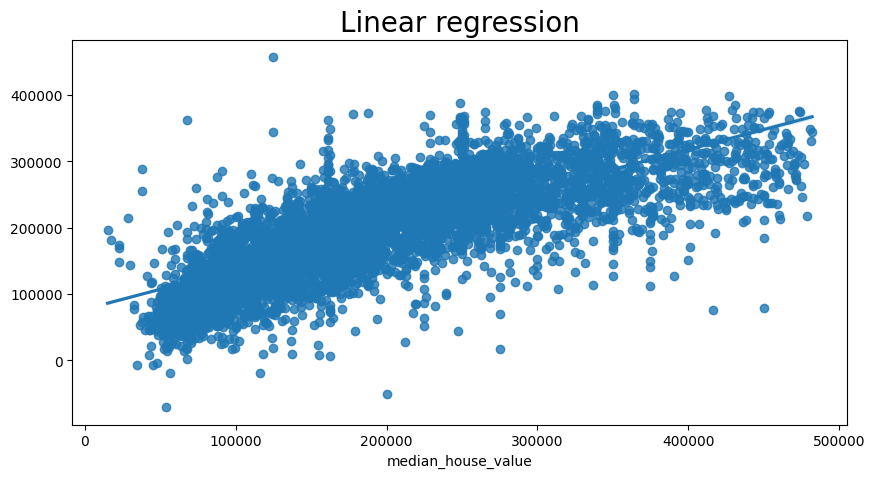

In [ ]:
plt.figure(figsize = (10,5))
sns.regplot(x=y_test,y=y_pred)
plt.title('Linear regression', fontsize = 20)

## 6.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Creating and training model
RandomForest_reg = RandomForestRegressor(n_estimators = 10, random_state = 0)

In [ ]:
RandomForest_reg.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = RandomForest_reg.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(RandomForest_reg,X_train,y_train,X_test,y_test,y_pred)]

rf_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rf_score.insert(0, 'Model', 'Random Forest')
rf_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest,0.717937,0.717252,0.70422,50729.968369


## 6.3 Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

# Creating and training model
ridge_reg = Ridge(alpha=3, solver="cholesky")

In [ ]:
ridge_reg.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = ridge_reg.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(ridge_reg,X_train,y_train,X_test,y_test,y_pred)]

rr_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rr_score.insert(0, 'Model', 'Ridge Regression')
rr_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Ridge Regression,0.599592,0.598619,0.606438,60442.622167


## 6.4 XGBoost

In [ ]:
from xgboost import XGBRegressor
# create an xgboost regression model
XGBR = XGBRegressor(n_estimators=1000, max_depth=7, eta=0.1, subsample=0.8, colsample_bytree=0.8)

In [ ]:
XGBR.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = XGBR.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(XGBR,X_train,y_train,X_test,y_test,y_pred)]

XGBR_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
XGBR_score.insert(0, 'Model', 'XGBoost')
XGBR_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,XGBoost,0.763256,0.762681,0.764309,46476.255258


## 6.5 Recursive Feature Elimination (RFE)

RFE adalah algoritme pemilihan fitur wrapper-type feature (tipe pembungkus). Artinya, algoritme pembelajaran mesin yang berbeda diberikan dan digunakan dalam inti metode, dibungkus oleh RFE, dan digunakan untuk membantu memilih fitur.

Random Forest biasanya memiliki kinerja yang baik jika dikombinasikan dengan RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

# create pipeline
rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=60)
model = RandomForestRegressor()
rf_pipeline = Pipeline(steps=[('s',rfe),('m',model)])

In [ ]:
rf_pipeline.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = rf_pipeline.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(rf_pipeline,X_train,y_train,X_test,y_test,y_pred)]

rfe_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rfe_score.insert(0, 'Model', 'Random Forest with RFE')
rfe_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest with RFE,0.745139,0.74452,0.729476,48221.779505


# 7. Final Model Evaluation

In [ ]:
predictions = pd.concat([rfe_score, XGBR_score, rr_score, rf_score, lm_score], ignore_index=True, sort=False)
predictions

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest with RFE,0.745139,0.744520,0.729476,48221.779505
1,XGBoost,0.763256,0.762681,0.764309,46476.255258
2,Ridge Regression,0.599592,0.598619,0.606438,60442.622167
3,Random Forest,0.717937,0.717252,0.704220,50729.968369
4,Linear Regression,0.598569,0.597594,0.606503,60519.779095


## 7.3 Visualizing Model Performance

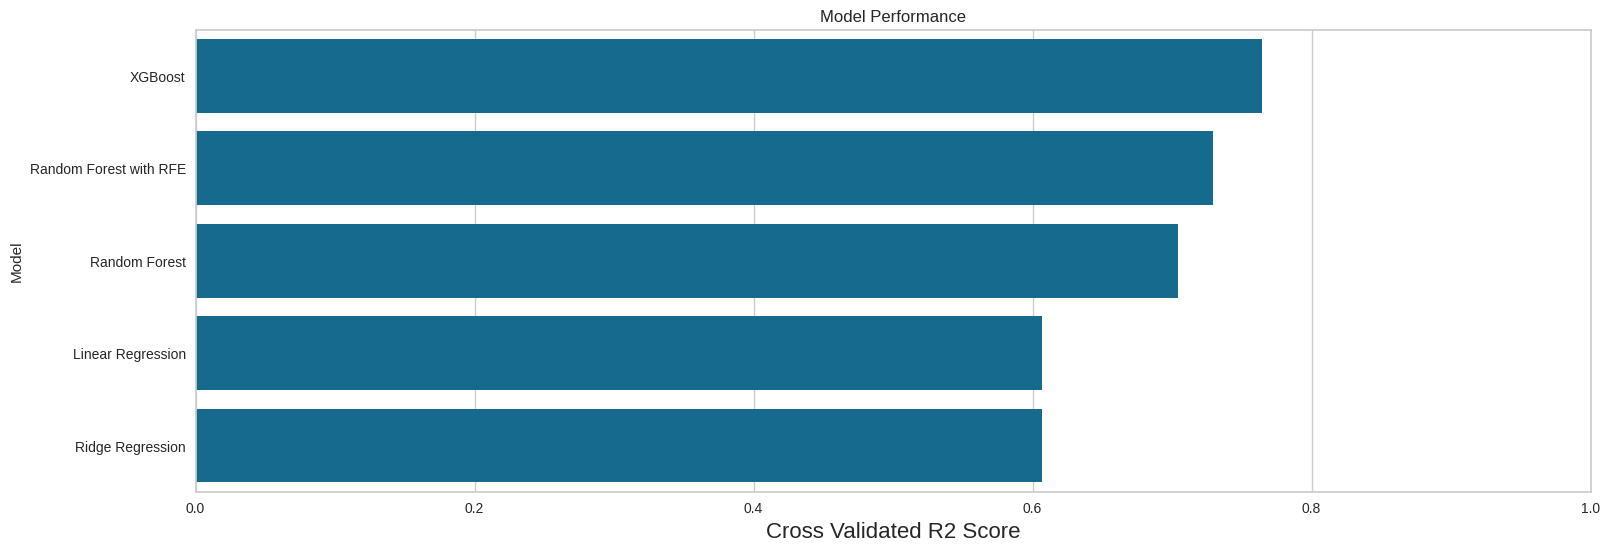

In [ ]:
f, axe = plt.subplots(1,1, figsize=(18,6))

predictions.sort_values(by=['Cross Validated R2 Score'], ascending=False, inplace=True)

sns.barplot(x='Cross Validated R2 Score', y='Model', data = predictions, ax = axe)
axe.set_xlabel('Cross Validated R2 Score', size=16)
axe.set_ylabel('Model')
axe.set_xlim(0,1.0)

axe.set(title='Model Performance')

plt.show()

# 8. Bonus: hyperparameter Tuning Using GridSearchCV

Hyperparameter tuning (Penyetelan hyperparameter) adalah proses penyetelan parameter yang ada sebagai tupel saat kita membangun model pembelajaran mesin. Parameter-parameter ini ditentukan oleh kita. Algoritma pembelajaran mesin tidak pernah mempelajari parameter ini. Ini dapat disetel dalam langkah yang berbeda.

GridSearchCV adalah teknik untuk menemukan nilai hyperparameter yang optimal dari sekumpulan parameter yang diberikan dalam sebuah kisi. Pada dasarnya ini adalah teknik validasi silang. Model serta parameter harus dimasukkan. Setelah mengekstrak nilai parameter terbaik, prediksi dibuat.

Parameter "terbaik" yang diidentifikasi oleh GridSearchCV secara teknis adalah yang terbaik yang dapat dihasilkan, tetapi hanya dengan parameter yang Anda masukkan dalam kisi parameter Anda.

## 8.1 Tuned Ridge Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial features are those features created by raising existing features to an exponent.
# For example, if a dataset had one input feature X,
# then a polynomial feature would be the addition of a new feature (column) where values were calculated by squaring the values in X, e.g. X^2.

steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge(alpha=3.8, fit_intercept=True))
]

ridge_pipe = Pipeline(steps)
ridge_pipe.fit(X_train, y_train)

# Model making a prediction on test data
y_pred = ridge_pipe.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV

alpha_params = [{'model__alpha': list(range(1, 15))}]

clf = GridSearchCV(ridge_pipe, alpha_params, cv = 10)

### Tuned Ridge Regression performance

In [ ]:
# Fit and tune model
clf.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = ridge_pipe.predict(X_test)
# The combination of hyperparameters along with values that give the best performance of our estimate specified
print(clf.best_params_)

{'model__alpha': 7}


In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(clf,X_train,y_train,X_test,y_test,y_pred)]

clf_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
clf_score.insert(0, 'Model', 'Tuned Ridge Regression')
clf_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Tuned Ridge Regression,-3.801188,-3.812849,0.577114,212342.488827


# 9. Final performance comparison

In [ ]:
result = pd.concat([clf_score, predictions], ignore_index=True, sort=False)
result

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Tuned Ridge Regression,-3.801188,-3.812849,0.577114,212342.488827
1,XGBoost,0.763256,0.762681,0.764309,46476.255258
2,Random Forest with RFE,0.745139,0.744520,0.729476,48221.779505
3,Random Forest,0.717937,0.717252,0.704220,50729.968369
4,Linear Regression,0.598569,0.597594,0.606503,60519.779095
5,Ridge Regression,0.599592,0.598619,0.606438,60442.622167


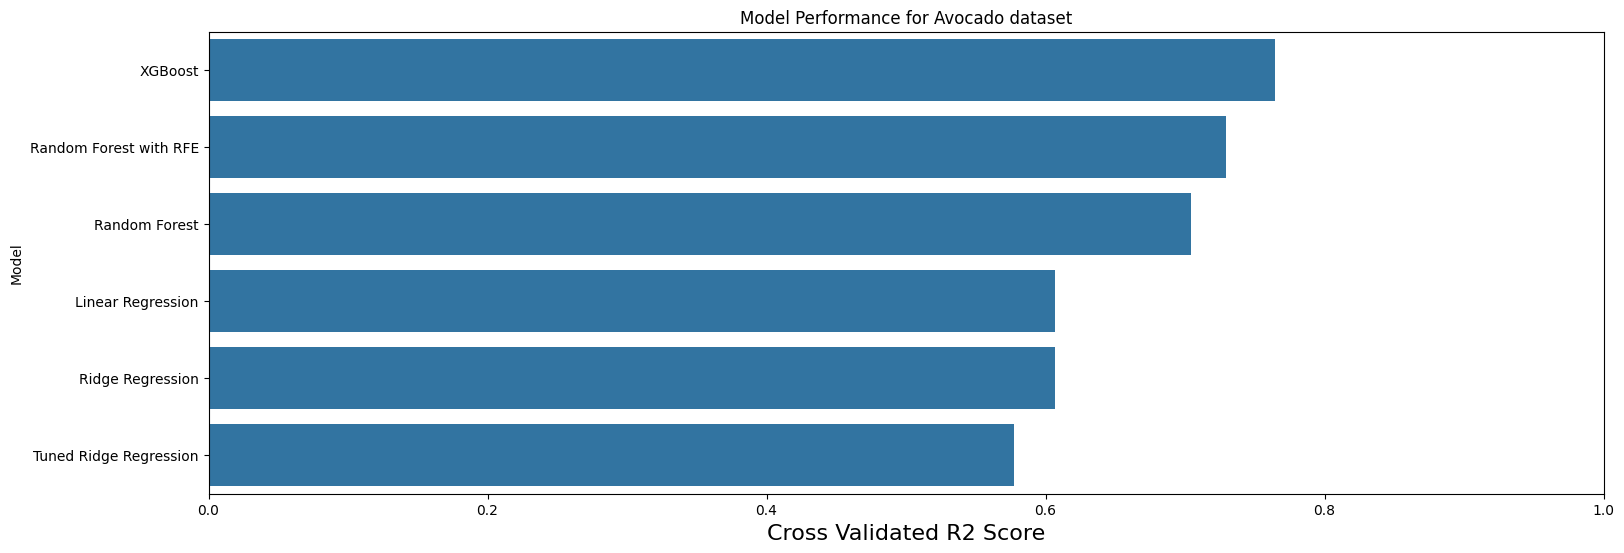

In [ ]:
f, axe = plt.subplots(1,1, figsize=(18,6))

result.sort_values(by=['Cross Validated R2 Score'], ascending=False, inplace=True)

sns.barplot(x='Cross Validated R2 Score', y='Model', data = result, ax = axe)
#axes[0].set(xlabel='Region', ylabel='Charges')
axe.set_xlabel('Cross Validated R2 Score', size=16)
axe.set_ylabel('Model')
axe.set_xlim(0,1.0)
axe.set(title='Model Performance for Avocado dataset')

plt.show()

## PYCARET

In [ ]:
pip install scipy-1.0.0-cp36-cp36m-win_amd64.whl

ERROR: scipy-1.0.0-cp36-cp36m-win_amd64.whl is not a supported wheel on this platform.


In [ ]:
pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.7/484.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 54.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 103.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 24.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 21.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 51.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.2 MB/

In [ ]:
from pycaret.regression import *


In [ ]:
reg = setup(data = df,
             target = 'median_house_value',
             numeric_imputation = 'median',
             categorical_features = ["ocean_proximity"],
             ignore_features = ['Alley','PoolQC','MiscFeature','Fence','FireplaceQu','Utilities'],
             normalize = True,
             verbose = False)

In [ ]:
compare_models()


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,32467.5638,2356393637.9419,48469.4886,0.8239,0.2410,0.1825,1.9620
rf,Random Forest Regressor,32353.6594,2473709555.3974,49674.6200,0.8151,0.2422,0.1816,6.2720
et,Extra Trees Regressor,35019.0675,2783179994.8595,52699.9012,0.7920,0.2539,0.1957,2.1580
gbr,Gradient Boosting Regressor,38734.1213,3113980963.1048,55748.4584,0.7673,0.2739,0.2181,1.6790
knn,K Neighbors Regressor,41624.6238,3814969216.0000,61727.4684,0.7148,0.2911,0.2254,0.2570
lar,Least Angle Regression,50079.9139,4788958541.8507,69151.4678,0.6422,0.3779,0.2875,0.0730
llar,Lasso Least Angle Regression,50079.8656,4788948285.9393,69151.4074,0.6422,0.3777,0.2875,0.0720
br,Bayesian Ridge,50076.8564,4788690206.8787,69149.7229,0.6422,0.3764,0.2874,0.1090
ridge,Ridge Regression,50079.0860,4788878806.0152,69150.9428,0.6422,0.3774,0.2875,0.0680
lasso,Lasso Regression,50079.8675,4788947384.2549,69151.4007,0.6422,0.3777,0.2875,0.1650


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

LGBMRegressor(n_jobs=-1, random_state=2485)

In [ ]:
lgb = create_model('lightgbm')


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,31245.8206,2113531917.2123,45973.1652,0.8442,0.2284,0.1715
1,29782.3646,1800213620.1574,42428.9243,0.8622,0.2190,0.1709
2,33161.7533,2650948322.2759,51487.3608,0.8072,0.2354,0.1717
3,33092.1749,2590627409.3191,50898.2063,0.8074,0.2521,0.1890
4,32316.8580,2352363005.9161,48501.1650,0.8167,0.2443,0.1860
5,33902.8322,2583680405.8612,50829.9164,0.8032,0.2545,0.1978
6,33158.6332,2382110393.4234,48806.8683,0.8286,0.2450,0.1873
7,31916.1845,2197833615.9210,46881.0582,0.8327,0.2353,0.1772
8,34068.5204,2571154333.4615,50706.5512,0.8116,0.2560,0.1922


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_lgb = tune_model(lgb)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,29755.9093,1955005081.6536,44215.4394,0.8559,0.2229,0.1630
1,27379.2548,1601237051.5876,40015.4602,0.8774,0.2062,0.1564
2,30342.1556,2299695923.5926,47955.1449,0.8328,0.2208,0.1564
3,30983.1936,2425138159.3599,49245.6918,0.8197,0.2466,0.1754
4,29953.1148,2149604074.8434,46363.8229,0.8325,0.2367,0.1726
5,32220.3249,2424241830.2556,49236.5904,0.8154,0.2488,0.1879
6,30888.4093,2150305948.8444,46371.3915,0.8453,0.2377,0.1752
7,29386.6927,1916033544.6697,43772.5204,0.8542,0.2211,0.1606
8,31920.6996,2309050510.4217,48052.5807,0.8308,0.2441,0.1791


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:
predictions = predict_model(tuned_lgb, data = test)
sample['SalePrice'] = predictions['median_house_value']
sample.to_csv('submission_house_price.csv',index=False)
sample.head()

NameError: name 'test' is not defined